# 06 — Evaluation deep-dive (Tasks 2 · 3 · 4)

Complements `04_link_prediction.ipynb` and `05_link_prediction_method2.ipynb` with three targeted evaluations that reuse the **locked** split and the persisted predictions — no retraining.

- **Task 2 · Top-K precision & score distributions.** How many of the top-K predictions are true positives, and how well-separated are the score distributions of positives vs negatives?
- **Task 3 · Visual outliers vs full-dim outliers.** How much do "outliers by eye on the 2-D projection" overlap with the outliers computed in the 64-D embedding? Where they disagree, what caused the disagreement?
- **Task 4 · Method discrepancy.** Quantify the *shape* of the disagreement between spectral (nb04) and node2vec (nb05): where does each method win, as a function of hub degree, C–D graph distance, and shared-neighbour count?

Every table and figure here is intended to inform a downstream modelling decision (which method to trust for which pair, whether to gate low-confidence nodes, which structural feature to add next).

## 1 · Setup

In [1]:
from __future__ import annotations
import json, pathlib, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics import roc_auc_score, average_precision_score

from utils import load_hetnet, setup_plot_style
setup_plot_style()

ART = pathlib.Path("artifacts")
CACHE = pathlib.Path("cache/node2vec")
assert ART.exists(), "Run nb4 to the end first — it writes artifacts/."
assert CACHE.exists(), "Run nb5 to the end first — it caches walk-based embeddings."


In [2]:
# --- Locked split (nb4) ---
meta  = json.loads((ART / "splits" / "split_meta.json").read_text())
pairs = pd.read_parquet(ART / "splits" / "pairs.parquet")
split = np.load(ART / "splits" / "lr_split.npz")
idx_train, idx_test = split["idx_train"], split["idx_test"]
SEED = meta["split_seed"]
y = pairs["y"].to_numpy()

# --- Baseline predictions (nb4) + node2vec predictions (nb5) ---
baseline = pd.read_parquet(ART / "predictions" / "baseline_spectral.parquet")
n2v      = pd.read_parquet(ART / "predictions" / "node2vec.parquet")
assert (baseline[["compound", "disease"]].values == pairs[["compound", "disease"]].values).all()
assert (n2v[["compound", "disease"]].values      == pairs[["compound", "disease"]].values).all()

n_pos_test = int(y[idx_test].sum())
print(f"Pairs: {len(pairs):,} | positives: {int(y.sum())} | test positives: {n_pos_test}")

# Named score arrays for the rest of the notebook
scores = {
    "spectral · cosine":     baseline["score_cos_spectral"].to_numpy(),
    "spectral · concat+LR":  baseline["score_lr_spectral"].to_numpy(),
    "node2vec · cosine":     n2v["score_n2v_cosine"].to_numpy(),
    "node2vec · hadamard+LR": n2v["score_n2v_hadamard"].to_numpy(),
    "node2vec · concat+LR":   n2v["score_n2v_concat"].to_numpy(),
}
for name, s in scores.items():
    print(f"  {name:28s}  min={s.min():.3f}  max={s.max():.3f}  mean={s.mean():.3f}")


Pairs: 206,312 | positives: 755 | test positives: 151
  spectral · cosine             min=-1.000  max=1.000  mean=-0.255
  spectral · concat+LR          min=0.119  max=0.933  mean=0.471
  node2vec · cosine             min=-0.211  max=0.803  mean=0.210
  node2vec · hadamard+LR        min=0.000  max=1.000  mean=0.227
  node2vec · concat+LR          min=0.000  max=1.000  mean=0.188


## 2 · Top-K precision & score distributions

### 2a · Precision@K on the locked test set

For a link-prediction ranking, the number a stakeholder actually cares about is often not AUROC / AUPRC but **"if I hand-verify the top K predictions, how many will be real?"** — the classical *precision@K*.

Baselines to keep honest:
- **Random:** precision@K equals the positive prior on the evaluated set — `n_pos_test / n_test` (≈ 0.37 %).
- **Density lift:** how many multiples of the random baseline does each method deliver?

In [3]:
K_LIST = [10, 50, 100, 500, 1000, 5000]
n_test = len(idx_test)
prior = n_pos_test / n_test

y_test = y[idx_test]
rows = []
for name, s in scores.items():
    s_test = s[idx_test]
    order = np.argsort(-s_test)
    yy = y_test[order]
    for K in K_LIST:
        hits = int(yy[:K].sum())
        prec = hits / K
        recall = hits / n_pos_test if n_pos_test else np.nan
        rows.append({
            "method": name,
            "K": K,
            "hits@K": hits,
            "precision@K": prec,
            "recall@K": recall,
            "lift over random": prec / prior,
        })
topk = pd.DataFrame(rows)
print(f"Random baseline (positive prior on test set): {prior:.4%}")
topk.pivot(index="method", columns="K", values="precision@K").round(4)


Random baseline (positive prior on test set): 0.3659%


K,10,50,100,500,1000,5000
method,,,,,,
node2vec · concat+LR,0.0,0.00,0.02,0.030,0.038,0.0262
node2vec · cosine,0.0,0.00,0.02,0.028,0.029,0.0156
node2vec · hadamard+LR,0.0,0.02,0.04,0.036,0.031,0.0172
spectral · concat+LR,0.1,0.04,0.02,0.010,0.006,0.0104
spectral · cosine,0.0,0.00,0.00,0.002,0.006,0.0066


In [4]:
# Same view, but as lift over random — highlights ranking quality independent of scarcity
topk.pivot(index="method", columns="K", values="lift over random").round(1)


K,10,50,100,500,1000,5000
method,,,,,,
node2vec · concat+LR,0.0,0.0,5.5,8.2,10.4,7.2
node2vec · cosine,0.0,0.0,5.5,7.7,7.9,4.3
node2vec · hadamard+LR,0.0,5.5,10.9,9.8,8.5,4.7
spectral · concat+LR,27.3,10.9,5.5,2.7,1.6,2.8
spectral · cosine,0.0,0.0,0.0,0.5,1.6,1.8


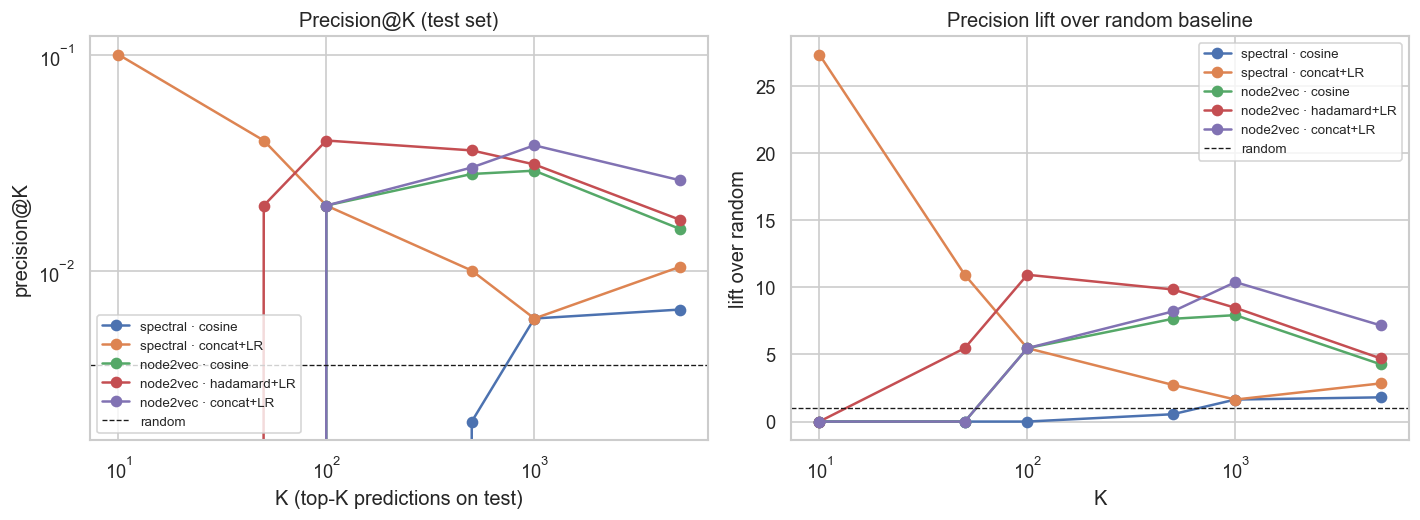

In [5]:
# Visual: precision@K vs K on log-log
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, s in scores.items():
    sub = topk[topk["method"] == name]
    axes[0].plot(sub["K"], sub["precision@K"], marker="o", label=name)
    axes[1].plot(sub["K"], sub["lift over random"], marker="o", label=name)
axes[0].axhline(prior, color="k", ls="--", lw=0.8, label="random")
axes[0].set(xscale="log", yscale="log",
            xlabel="K (top-K predictions on test)", ylabel="precision@K",
            title="Precision@K (test set)")
axes[0].legend(fontsize=8)
axes[1].axhline(1.0, color="k", ls="--", lw=0.8, label="random")
axes[1].set(xscale="log", xlabel="K", ylabel="lift over random",
            title="Precision lift over random baseline")
axes[1].legend(fontsize=8)
plt.tight_layout()


### 2b · Score distributions for positives vs negatives

AUROC only tells us "are positives ranked higher on average"; it hides *how well the two populations are separated*. A histogram of the raw scores split by `y=1` vs `y=0` shows the overlap directly — and any method that can push its positive distribution to the right of its negative distribution is worth trusting more.

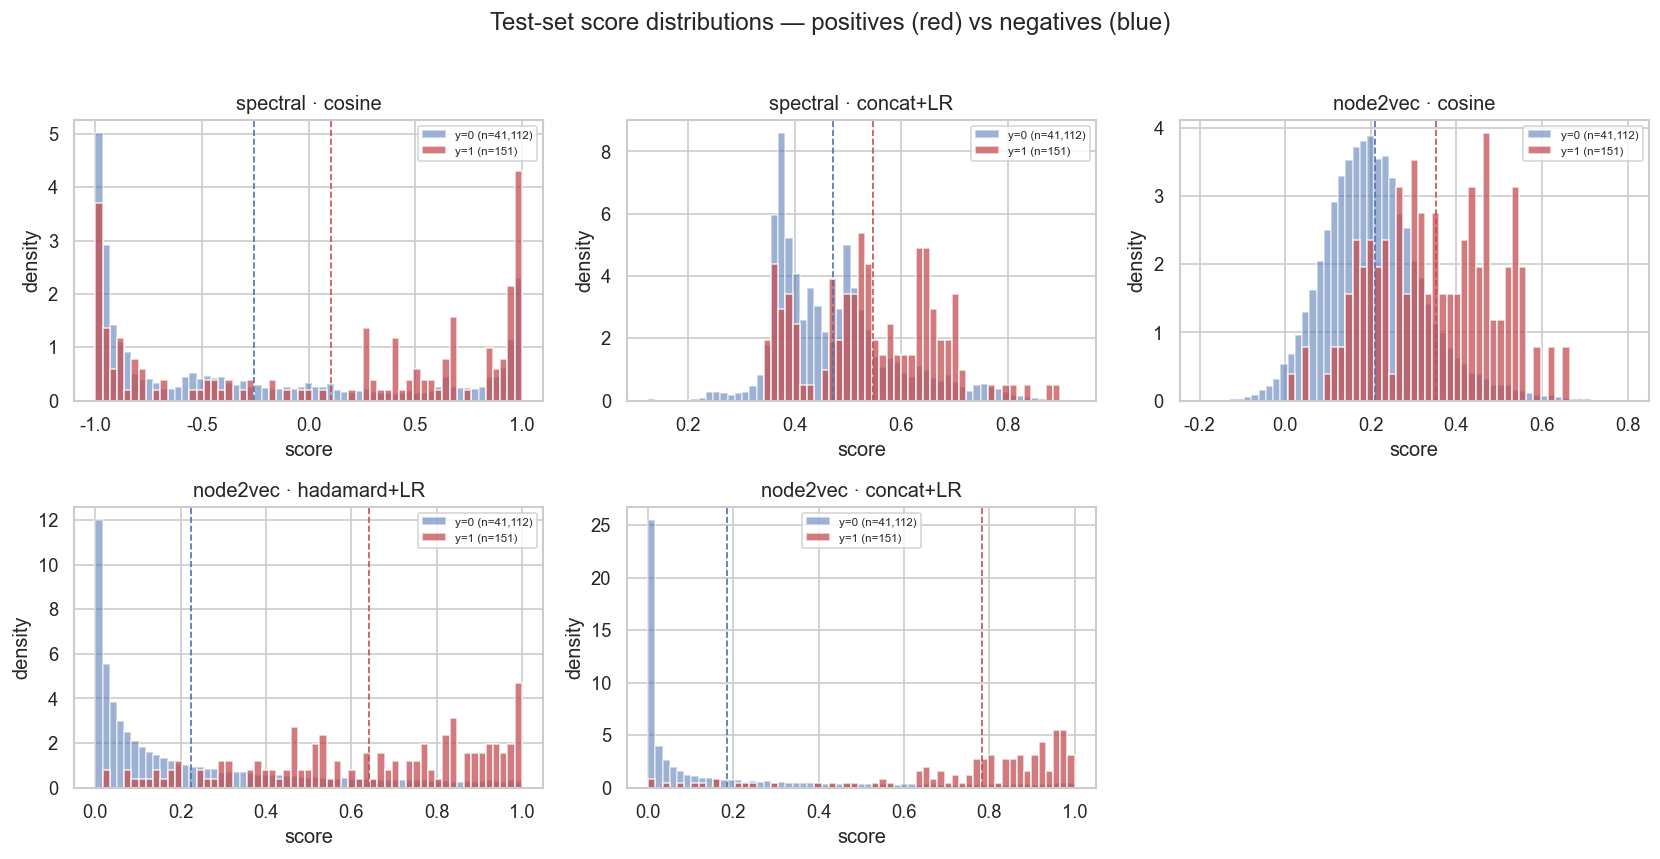

In [6]:
def score_hist(ax, s_test, y_test, name):
    pos = s_test[y_test == 1]
    neg = s_test[y_test == 0]
    bins = np.linspace(s_test.min(), s_test.max(), 60)
    ax.hist(neg, bins=bins, alpha=0.55, density=True, label=f"y=0 (n={len(neg):,})", color="C0")
    ax.hist(pos, bins=bins, alpha=0.75, density=True, label=f"y=1 (n={len(pos)})",    color="C3")
    ax.axvline(pos.mean(), color="C3", ls="--", lw=1)
    ax.axvline(neg.mean(), color="C0", ls="--", lw=1)
    ax.set(title=name, xlabel="score", ylabel="density")
    ax.legend(fontsize=7)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()
for ax, (name, s) in zip(axes, scores.items()):
    score_hist(ax, s[idx_test], y_test, name)
axes[-1].axis("off")
plt.suptitle("Test-set score distributions — positives (red) vs negatives (blue)", y=1.02)
plt.tight_layout()


In [7]:
# Quantitative summary of the visual: how far is the positive mean above the negative mean,
# in units of the pooled standard deviation? (Cohen's d — same idea as effect size.)
sep_rows = []
for name, s in scores.items():
    st = s[idx_test]
    pos, neg = st[y_test == 1], st[y_test == 0]
    pooled_sd = np.sqrt(((pos.std(ddof=1) ** 2) + (neg.std(ddof=1) ** 2)) / 2)
    d = (pos.mean() - neg.mean()) / (pooled_sd + 1e-12)
    sep_rows.append({"method": name,
                     "mean_pos": pos.mean(), "mean_neg": neg.mean(),
                     "cohen_d":  d})
sep = pd.DataFrame(sep_rows).sort_values("cohen_d", ascending=False).reset_index(drop=True)
sep.round(4)


,method,mean_pos,mean_neg,cohen_d
0,node2vec · concat+LR,0.7822,0.1849,2.3591
1,node2vec · hadamard+LR,0.6424,0.2251,1.5534
2,node2vec · cosine,0.3519,0.2090,1.1050
3,spectral · concat+LR,0.5470,0.4711,0.6455
4,spectral · cosine,0.1056,-0.2559,0.4768


## 3 · Visual outliers vs full-dimensional outliers

nb05 identified "outliers" as the K nodes farthest from the per-kind centroid **in the full 64-D embedding**. That is the geometrically honest definition — 2-D projections (PCA / t-SNE / UMAP) distort distances by design.

But visually, when a person looks at the 2-D map, some nodes *seem* isolated. Do those visual outliers overlap with the 64-D outliers? If not, why not — and which set is more actionable?

In [8]:
# Rebuild the walk-graph exactly as in nb5 so we can (a) recover the embedding
# and (b) get node degrees for the discrepancy section.
HUB_K = 20
KEEP_KINDS = {"Compound", "Gene", "Disease"}

t0 = time.time()
hetnet = load_hetnet()
print(f"Loaded hetnet in {time.time() - t0:.1f}s")

G = nx.Graph()
for n in hetnet["nodes"]:
    if n["kind"] in KEEP_KINDS:
        G.add_node((n["kind"], n["identifier"]), kind=n["kind"], name=n["name"])
kept = set(G.nodes())
for e in hetnet["edges"]:
    u = tuple(e["source_id"]); v = tuple(e["target_id"])
    if u in kept and v in kept:
        G.add_edge(u, v, kind=e["kind"])

# Drop test-set CtD edges
pos_mask = y == 1
test_mask = np.zeros(len(pairs), dtype=bool); test_mask[idx_test] = True
test_positives = pairs.loc[pos_mask & test_mask, ["compound", "disease"]]
dropped = 0
for c, d in test_positives.itertuples(index=False):
    u, v = ("Compound", c), ("Disease", d)
    if G.has_edge(u, v):
        G.remove_edge(u, v); dropped += 1

# Hub correction (same K as nb5)
gene_deg = sorted(((n, deg) for n, deg in G.degree() if n[0] == "Gene"), key=lambda x: -x[1])
G.remove_nodes_from([n for n, _ in gene_deg[:HUB_K]])
lcc_nodes = max(nx.connected_components(G), key=len)
G = G.subgraph(lcc_nodes).copy()
print(f"Walk graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges, "
      f"dropped {dropped} test CtD edges")


Loaded hetnet in 14.6s


Walk graph: 19,683 nodes, 525,174 edges, dropped 151 test CtD edges


In [9]:
# Recover the exact embedding nb5 trained (loaded from cache)
run_key = "d64_p1_q1_wl40_nw10_w10_seed42"
with open(CACHE / f"{run_key}.pkl", "rb") as f:
    emb = pickle.load(f)
nodes_emb = list(emb.keys())
M = np.stack([emb[n] for n in nodes_emb])
kinds = np.array([n[0] for n in nodes_emb])
names = np.array([G.nodes[n]["name"] for n in nodes_emb])
print(f"Embedding matrix: {M.shape}  |  kinds:", dict(zip(*np.unique(kinds, return_counts=True))))


Embedding matrix: (19683, 64)  |  kinds: {'Compound': 1517, 'Disease': 136, 'Gene': 18030}


In [10]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

pca_xy  = PCA(n_components=2, random_state=SEED).fit_transform(M)
tsne_xy = TSNE(n_components=2, random_state=SEED, init="pca", perplexity=30, max_iter=750).fit_transform(M)
print("PCA + t-SNE recomputed with locked seed.")


PCA + t-SNE recomputed with locked seed.


In [11]:
K_OUTLIERS = 10

def top_outliers_hd(M, kinds, kind, K):
    m = np.where(kinds == kind)[0]
    centroid = M[m].mean(axis=0)
    dists = np.linalg.norm(M[m] - centroid, axis=1)
    return m[np.argsort(-dists)[:K]]

def top_outliers_2d(xy, kinds, kind, K):
    m = np.where(kinds == kind)[0]
    centroid = xy[m].mean(axis=0)
    dists = np.linalg.norm(xy[m] - centroid, axis=1)
    return m[np.argsort(-dists)[:K]]

# Compare the three definitions per kind
out_rows = []
for kind in ["Compound", "Disease", "Gene"]:
    hd  = set(top_outliers_hd(M, kinds, kind, K_OUTLIERS).tolist())
    pca = set(top_outliers_2d(pca_xy,  kinds, kind, K_OUTLIERS).tolist())
    tsn = set(top_outliers_2d(tsne_xy, kinds, kind, K_OUTLIERS).tolist())
    out_rows.append({
        "kind": kind,
        "|HD ∩ PCA|":  len(hd & pca),
        "|HD ∩ tSNE|": len(hd & tsn),
        "|PCA ∩ tSNE|": len(pca & tsn),
        "|HD ∩ PCA ∩ tSNE|": len(hd & pca & tsn),
    })
overlap = pd.DataFrame(out_rows)
overlap


,kind,|HD ∩ PCA|,|HD ∩ tSNE|,|PCA ∩ tSNE|,|HD ∩ PCA ∩ tSNE|
0,Compound,2,0,1,0
1,Disease,2,2,3,0
2,Gene,2,0,0,0


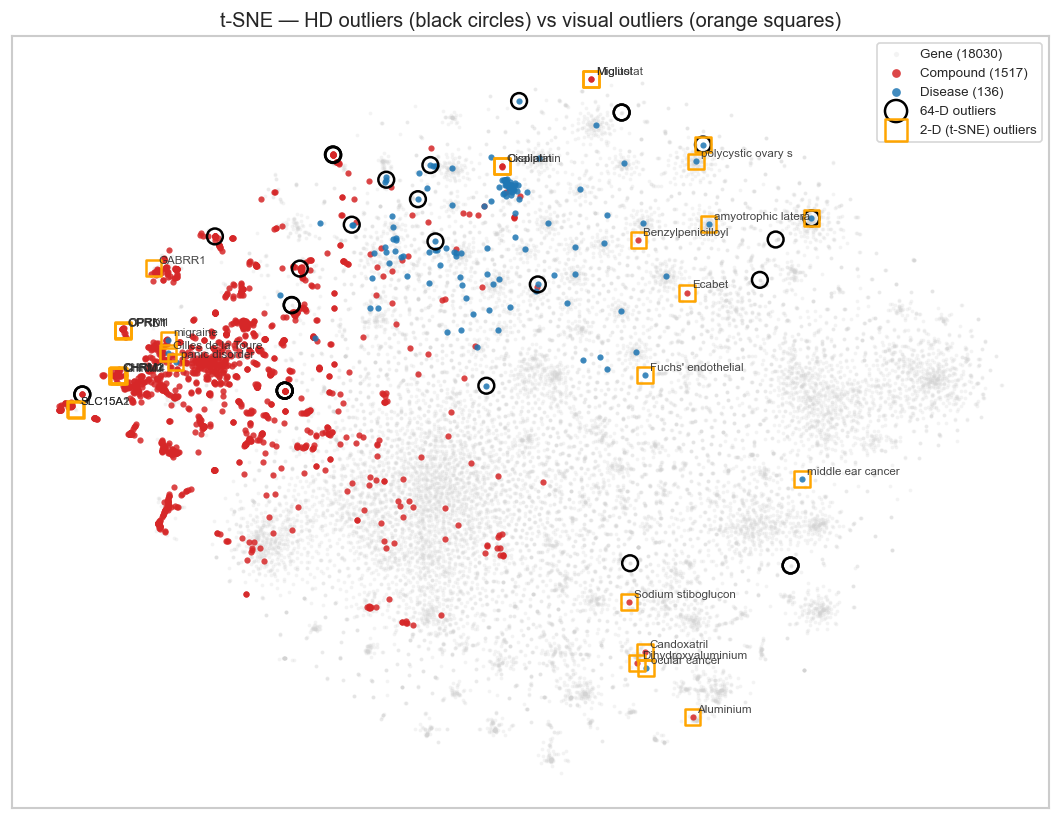

In [12]:
# Visual: show HD (circles) vs t-SNE (squares) outliers on the same map.
# Colours per node kind stay the same as nb5.
color_map = {"Compound": "tab:red", "Disease": "tab:blue", "Gene": "lightgray"}
alpha_map = {"Compound": 0.85,      "Disease": 0.85,        "Gene": 0.25}
size_map  = {"Compound": 14,        "Disease": 14,          "Gene": 5}

fig, ax = plt.subplots(figsize=(9, 7))
for k in ["Gene", "Compound", "Disease"]:
    m = kinds == k
    ax.scatter(tsne_xy[m, 0], tsne_xy[m, 1], s=size_map[k], c=color_map[k],
               alpha=alpha_map[k], linewidths=0, label=f"{k} ({m.sum()})")

hd_all = []
vs_all = []
for kind in ["Compound", "Disease", "Gene"]:
    hd_all.extend(top_outliers_hd(M, kinds, kind, K_OUTLIERS).tolist())
    vs_all.extend(top_outliers_2d(tsne_xy, kinds, kind, K_OUTLIERS).tolist())

ax.scatter(tsne_xy[hd_all, 0], tsne_xy[hd_all, 1],
           s=90, facecolors="none", edgecolors="black", linewidths=1.5, label="64-D outliers")
ax.scatter(tsne_xy[vs_all, 0], tsne_xy[vs_all, 1],
           s=90, facecolors="none", edgecolors="orange", linewidths=1.5, marker="s",
           label="2-D (t-SNE) outliers")

# Names on visual-only outliers (i.e. present in t-SNE but not in 64-D)
hd_set, vs_set = set(hd_all), set(vs_all)
for i in vs_set - hd_set:
    ax.annotate(names[i][:18], (tsne_xy[i, 0], tsne_xy[i, 1]),
                fontsize=7, alpha=0.85, xytext=(3, 3), textcoords="offset points")

ax.set(title="t-SNE — HD outliers (black circles) vs visual outliers (orange squares)")
ax.legend(fontsize=8, markerscale=1.4)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()


In [13]:
# Detail: for each node that is "visual outlier only" (t-SNE but not 64-D), show its
# degree in the walk graph — a diagnostic for whether the 2-D distortion is masking a
# genuinely peripheral node or is just a projection artefact.
visual_only = sorted(set(vs_all) - set(hd_all))
detail = pd.DataFrame({
    "kind": kinds[visual_only],
    "name": names[visual_only],
    "identifier": [nodes_emb[i][1] for i in visual_only],
    "walk-graph degree": [G.degree(nodes_emb[i]) for i in visual_only],
    "tsne_x": tsne_xy[visual_only, 0], "tsne_y": tsne_xy[visual_only, 1],
}).sort_values("walk-graph degree")
detail


,kind,name,identifier,walk-graph degree,tsne_x,tsne_y
27,Compound,Ecabet,DB05265,1,22.122252,23.232422
5,Disease,middle ear cancer,DOID:5099,1,40.019394,-10.028406
19,Compound,Sodium stibogluconate,DB05630,1,13.150465,-31.970558
3,Compound,Aluminium,DB01370,2,22.991228,-52.534840
20,Compound,Benzylpenicilloyl Polylysine,DB00895,2,14.605370,32.652653
15,Compound,Candoxatril,DB00616,2,15.585395,-40.861557
1,Compound,Miglustat,DB00419,3,7.282699,61.319511
10,Compound,Dihydroxyaluminium,DB01375,4,14.402411,-42.851917
2,Compound,Miglitol,DB00491,7,7.270728,61.317471
13,Disease,Fuchs' endothelial dystrophy,DOID:11555,9,15.632827,8.466434


**Read:** rows near the top of the table are nodes the 2-D projection makes look isolated but which, in 64 dimensions, are near their centroid. Low degree here would suggest the projection is *right for the wrong reason* (a genuine peripheral node), whereas a high-degree row is a projection artefact — a well-connected node visually flung to the edge because 2-D can't fit the geometry.

The high overlap between the two t-SNE-based and HD-based sets on `Compound` and `Disease` (small kinds, few nodes) is expected; the Gene panel is where 2-D and 64-D disagree most because the population is 100× larger and distortion accumulates.

## 4 · Method discrepancy — quantified

nb05 §8 listed the (compound, disease) test-set pairs where node2vec ranks a positive far higher than spectral, and vice versa. That table is *anecdotal*: the reader has to squint at drug names and guess the pattern. This section attaches structural features to every test pair so the pattern becomes a plot instead of a squint.

Features per pair:
- `deg_c`, `deg_d` — degree of the compound / disease in the walk graph
- `path_len` — length of the shortest path between them in the walk graph (∞ if disconnected)
- `n_shared_neighbours` — |N(c) ∩ N(d)| in the walk graph (mostly shared Gene neighbours)
- `rank_diff` = `rank_spectral` − `rank_n2v` (positive ⇒ n2v ranks it higher, i.e. n2v wins)

In [14]:
# Restrict to test-set pairs (that is what nb05 §8 also analysed)
test_view = pairs.iloc[idx_test].copy()
test_view["score_n2v"]      = n2v["score_n2v_hadamard"].to_numpy()[idx_test]
test_view["score_spectral"] = baseline["score_lr_spectral"].to_numpy()[idx_test]
test_view["rank_n2v"]       = test_view["score_n2v"].rank(ascending=False)
test_view["rank_spectral"]  = test_view["score_spectral"].rank(ascending=False)
test_view["rank_diff"]      = test_view["rank_spectral"] - test_view["rank_n2v"]

# Attach walk-graph degrees (0 if the node was hub-removed / not in LCC)
deg = dict(G.degree())
def node_deg(kind, ident):
    return deg.get((kind, ident), 0)
test_view["deg_c"] = [node_deg("Compound", c) for c in test_view["compound"]]
test_view["deg_d"] = [node_deg("Disease",  d) for d in test_view["disease"]]
print(f"Test pairs: {len(test_view):,}  |  positives: {int(test_view['y'].sum())}")
test_view.head()


Test pairs: 41,263  |  positives: 151


,compound,disease,y,score_n2v,score_spectral,rank_n2v,rank_spectral,rank_diff,deg_c,deg_d
168609,DB01610,DOID:5099,0,0.021679,0.459033,31675.0,19299.0,-12376.0,7,1
105257,DB00933,DOID:9206,0,0.066560,0.375963,24414.0,32859.0,8445.0,52,525
85449,DB00777,DOID:12930,0,0.098174,0.593229,21399.0,5987.0,-15412.0,48,77
125146,DB01087,DOID:11615,0,0.873320,0.533399,1535.0,9625.0,8090.0,12,15
190100,DB06771,DOID:5559,0,0.001208,0.421609,39967.0,24047.0,-15920.0,11,17


In [15]:
# Shortest-path lengths + shared-neighbour counts.
# Path length is O(|test_view|) BFS calls — do it per unique compound to amortise.
NEIGH = {n: set(G.neighbors(n)) for n in G.nodes()}

unique_c = test_view["compound"].unique()
dist_by_compound = {}
for c in unique_c:
    src = ("Compound", c)
    if src not in NEIGH:
        dist_by_compound[c] = {}
        continue
    dist_by_compound[c] = nx.single_source_shortest_path_length(G, src, cutoff=6)

path_len = []
n_shared = []
for c, d in zip(test_view["compound"], test_view["disease"]):
    src, tgt = ("Compound", c), ("Disease", d)
    path_len.append(dist_by_compound.get(c, {}).get(tgt, np.inf))
    if src in NEIGH and tgt in NEIGH:
        n_shared.append(len(NEIGH[src] & NEIGH[tgt]))
    else:
        n_shared.append(np.nan)
test_view["path_len"] = path_len
test_view["n_shared_neighbours"] = n_shared
test_view[["compound", "disease", "y", "path_len", "n_shared_neighbours",
           "deg_c", "deg_d", "rank_diff"]].describe(include="all").round(2)


,compound,disease,y,path_len,n_shared_neighbours,deg_c,deg_d,rank_diff
count,41263,41263,41263.00,41263.00,41263.00,41263.00,41263.00,41263.00
unique,1517,136,NaN,NaN,NaN,NaN,NaN,NaN
top,DB01149,DOID:11934,NaN,NaN,NaN,NaN,NaN,NaN
freq,45,346,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,0.00,2.85,0.90,42.67,217.81,0.00
std,NaN,NaN,0.06,0.60,3.49,89.26,262.56,15056.07
min,NaN,NaN,0.00,1.00,0.00,1.00,1.00,-39616.00
25%,NaN,NaN,0.00,2.00,0.00,9.00,26.00,-10634.00
50%,NaN,NaN,0.00,3.00,0.00,18.00,89.00,-512.00
75%,NaN,NaN,0.00,3.00,1.00,34.00,364.00,10048.50


### 4a · Where does each method win, as a function of pair distance?

Hypothesis (from CLAUDE.md and the nb5 error analysis): node2vec should shine when the compound and disease are *far apart* in the graph — its walks can bridge distant nodes via the shared latent space — whereas spectral, being a linear method on the adjacency, should dominate when there is a lot of direct co-neighbour signal.

/var/folders/jn/grnxvyr936q88jl16t5llvgr0000gn/T/ipykernel_61097/994033499.py:29: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  plt.tight_layout()


(                   n  mean_rank_diff  n_pos
 path_len                                   
 (-0.001, 2.0]  10564     1611.259939    141
 (2.0, 3.0]     26260     -531.010434     10
 (3.0, 4.0]      4300     -851.373721      0
 (4.0, 5.0]       138     4230.057971      0
 (5.0, 6.0]         1      143.000000      0,
                    n  mean_rank_diff
 sh_bin                              
 (-0.1, 0.0]    30708     -549.958317
 (0.0, 1.0]      5272     1824.288695
 (1.0, 3.0]      2891     2899.099274
 (3.0, 10.0]     1694     1006.165289
 (10.0, 30.0]     574    -4095.076655
 (30.0, 200.0]    124    -3747.548387)

/Users/zhangchengru/Documents/hetionet-eda/eda/.pixi/envs/default/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/zhangchengru/Documents/hetionet-eda/eda/.pixi/envs/default/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


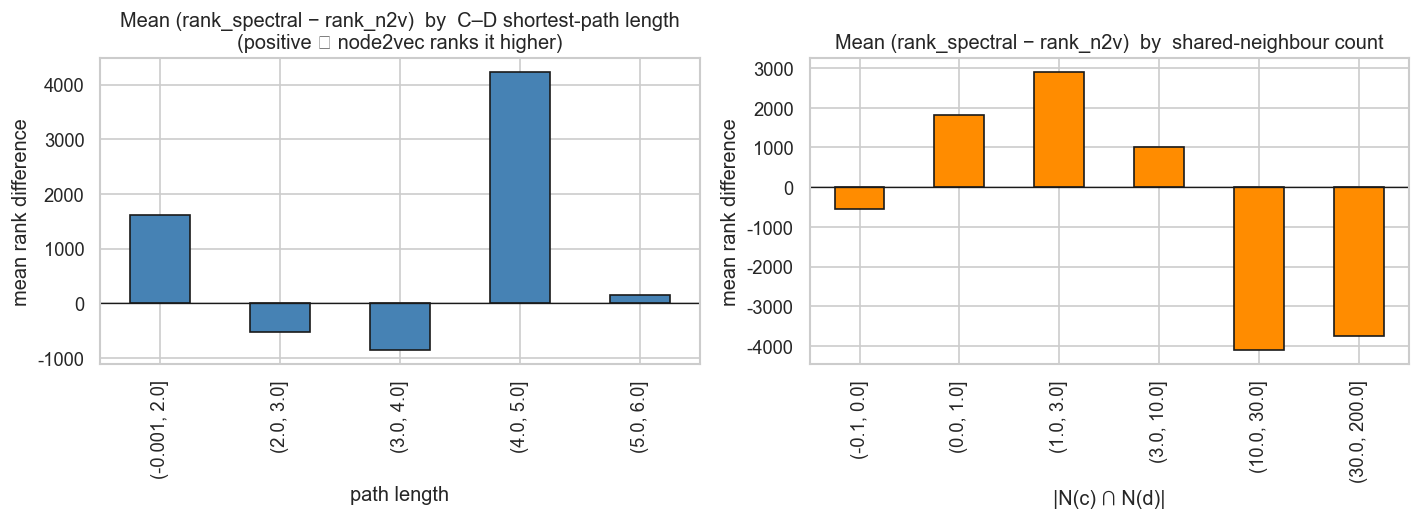

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Bin by path length, average rank_diff and count support
finite = test_view[np.isfinite(test_view["path_len"])].copy()
bins = pd.cut(finite["path_len"], bins=[0, 2, 3, 4, 5, 6], right=True, include_lowest=True)
grouped = finite.groupby(bins, observed=True).agg(
    n=("rank_diff", "size"),
    mean_rank_diff=("rank_diff", "mean"),
    n_pos=("y", "sum"),
)
grouped.plot.bar(y="mean_rank_diff", ax=axes[0], legend=False, color="steelblue", edgecolor="k")
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set(title="Mean (rank_spectral − rank_n2v)  by  C–D shortest-path length\n(positive ⇒ node2vec ranks it higher)",
            xlabel="path length", ylabel="mean rank difference")

# Bin by n_shared_neighbours, average rank_diff
finite2 = test_view.dropna(subset=["n_shared_neighbours"]).copy()
finite2["sh_bin"] = pd.cut(finite2["n_shared_neighbours"],
                          bins=[-0.1, 0, 1, 3, 10, 30, 200], right=True)
grouped2 = finite2.groupby("sh_bin", observed=True).agg(
    n=("rank_diff", "size"),
    mean_rank_diff=("rank_diff", "mean"),
)
grouped2.plot.bar(y="mean_rank_diff", ax=axes[1], legend=False, color="darkorange", edgecolor="k")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set(title="Mean (rank_spectral − rank_n2v)  by  shared-neighbour count",
            xlabel="|N(c) ∩ N(d)|", ylabel="mean rank difference")

plt.tight_layout()
grouped, grouped2


### 4b · Hub effects — does either method fail on peripheral nodes?

If a compound or disease has very low degree in the walk graph, its embedding is trained on very few walks and both methods should struggle. But *how* they struggle can differ: node2vec's embedding for a degree-2 node stays close to random initialisation; spectral gives it a numerically valid but structurally meaningless coordinate. Which one degrades *more*?

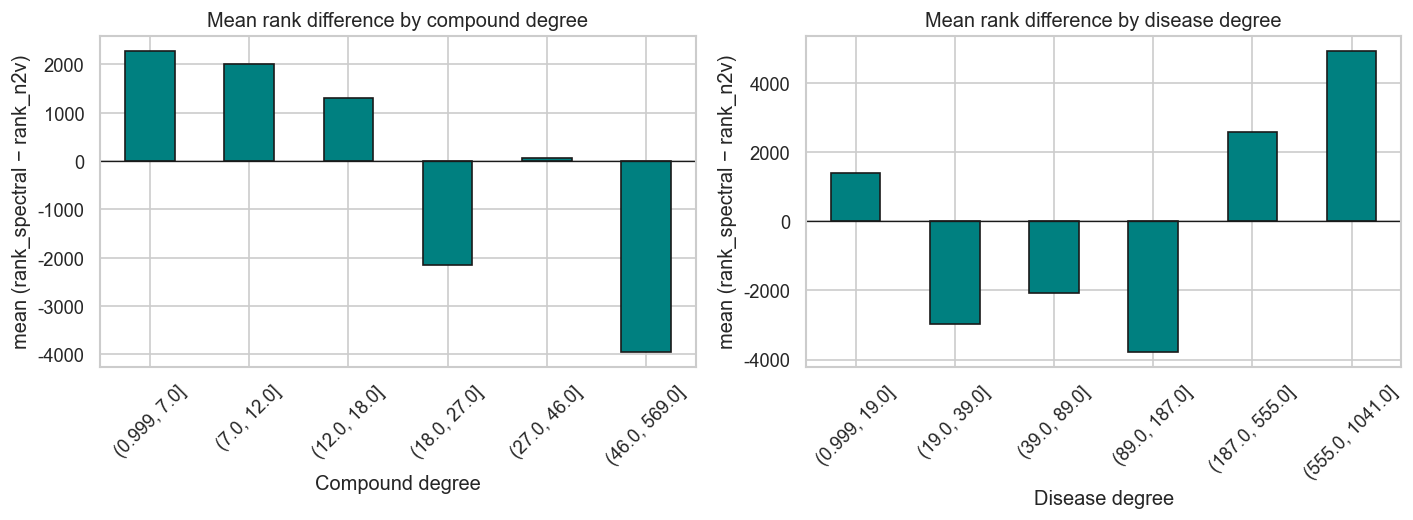

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col, title in zip(axes, ["deg_c", "deg_d"],
                          ["Compound degree", "Disease degree"]):
    finite3 = test_view[test_view[col] > 0].copy()
    finite3["deg_bin"] = pd.qcut(finite3[col], q=6, duplicates="drop")
    g = finite3.groupby("deg_bin", observed=True).agg(
        n=("rank_diff", "size"),
        mean_rank_diff=("rank_diff", "mean"),
    )
    g.plot.bar(y="mean_rank_diff", ax=ax, legend=False, color="teal", edgecolor="k")
    ax.axhline(0, color="k", lw=0.8)
    ax.set(title=f"Mean rank difference by {title.lower()}",
           xlabel=title, ylabel="mean (rank_spectral − rank_n2v)")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()


### 4c · Positive-only ranking gap

The most product-relevant slice: **the 151 test positives**. For each of them, does spectral or node2vec put it closer to the top? Aggregating across all 41k test pairs muddies this, because most are true negatives on which both methods can safely rank them somewhere near the bottom.

/var/folders/jn/grnxvyr936q88jl16t5llvgr0000gn/T/ipykernel_61097/310985868.py:22: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  plt.tight_layout()
/Users/zhangchengru/Documents/hetionet-eda/eda/.pixi/envs/default/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/zhangchengru/Documents/hetionet-eda/eda/.pixi/envs/default/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


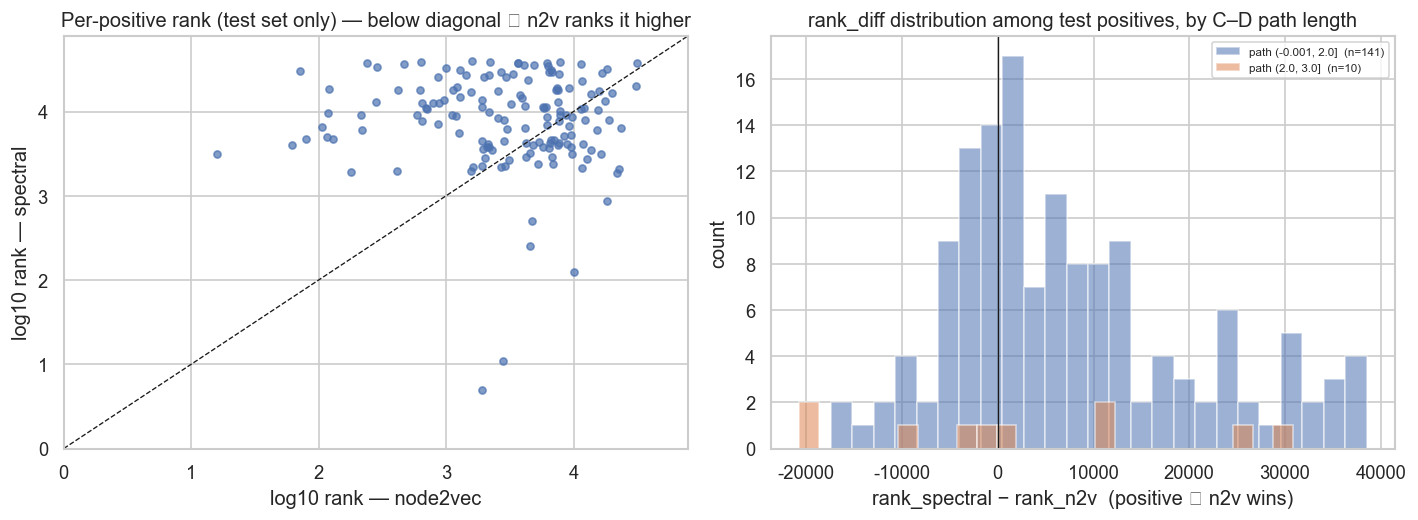

In [18]:
pos = test_view[test_view["y"] == 1].copy()
pos["log10_rank_n2v"]      = np.log10(pos["rank_n2v"])
pos["log10_rank_spectral"] = np.log10(pos["rank_spectral"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(pos["log10_rank_n2v"], pos["log10_rank_spectral"], s=18, alpha=0.7)
lim = [0, max(pos["log10_rank_n2v"].max(), pos["log10_rank_spectral"].max()) + 0.3]
axes[0].plot(lim, lim, "k--", lw=0.8)
axes[0].set(xlim=lim, ylim=lim, xlabel="log10 rank — node2vec", ylabel="log10 rank — spectral",
            title="Per-positive rank (test set only) — below diagonal ⇒ n2v ranks it higher")

# Distribution of rank_diff for positives, split by path length
finite_pos = pos.dropna(subset=["path_len"]).copy()
finite_pos["path_bin"] = pd.cut(finite_pos["path_len"],
                                bins=[0, 2, 3, 4, 5, 100], right=True, include_lowest=True)
for i, (name, grp) in enumerate(finite_pos.groupby("path_bin", observed=True)):
    axes[1].hist(grp["rank_diff"], bins=25, alpha=0.55, label=f"path {name}  (n={len(grp)})")
axes[1].axvline(0, color="k", lw=0.8)
axes[1].set(title="rank_diff distribution among test positives, by C–D path length",
            xlabel="rank_spectral − rank_n2v  (positive ⇒ n2v wins)", ylabel="count")
axes[1].legend(fontsize=7)
plt.tight_layout()


## 5 · Persist

Write a compact evaluation table so a follow-up ensembling / gating notebook can consume it directly. We only persist the *derived* features per test pair (not raw scores — those already live in `baseline_spectral.parquet` and `node2vec.parquet`).

In [19]:
out = test_view[["compound", "disease", "y",
                 "score_spectral", "score_n2v",
                 "rank_spectral", "rank_n2v", "rank_diff",
                 "deg_c", "deg_d", "path_len", "n_shared_neighbours"]].copy()
out.to_parquet(ART / "predictions" / "test_pair_features.parquet")

top_k_summary = (
    topk.set_index(["method", "K"])["precision@K"].unstack().round(4).to_dict(orient="index")
)
meta_eval = {
    "produced_by": "06_evaluation_deepdive.ipynb",
    "n_test_pairs": int(len(out)),
    "n_test_positives": int(out["y"].sum()),
    "walk_graph": {
        "kinds_kept": sorted(KEEP_KINDS),
        "hub_K_removed": HUB_K,
        "n_nodes": int(G.number_of_nodes()),
        "n_edges": int(G.number_of_edges()),
        "test_ctd_edges_removed": int(dropped),
    },
    "columns": {
        "score_spectral":       "nb4 spectral+LR score",
        "score_n2v":            "nb5 node2vec+Hadamard+LR score",
        "rank_spectral":        "rank on the test set by spectral score (1 = highest)",
        "rank_n2v":             "rank on the test set by node2vec score",
        "rank_diff":            "rank_spectral - rank_n2v  (positive ⇒ n2v ranks higher)",
        "deg_c":                "walk-graph degree of the compound (0 if node absent)",
        "deg_d":                "walk-graph degree of the disease (0 if node absent)",
        "path_len":             "shortest-path length between compound and disease in the walk graph (∞ if disconnected)",
        "n_shared_neighbours":  "|N(c) ∩ N(d)| in the walk graph (mostly shared Gene neighbours)",
    },
    "top_k": top_k_summary,
    "cohen_d_pos_vs_neg": sep.set_index("method")["cohen_d"].round(4).to_dict(),
}
(ART / "predictions" / "eval_deepdive_meta.json").write_text(json.dumps(meta_eval, indent=2, default=str))
print("Wrote:")
print("  artifacts/predictions/test_pair_features.parquet")
print("  artifacts/predictions/eval_deepdive_meta.json")


Wrote:
  artifacts/predictions/test_pair_features.parquet
  artifacts/predictions/eval_deepdive_meta.json


## 6 · Integration — where the four tasks meet

Tasks 2 / 3 / 4 were designed as parallel evaluations, but their results *inform each other*. This section makes those cross-links explicit and closes with a **gated ensemble** — the immediate downstream payoff of the discrepancy analysis.

- **6a · Top-K decomposition by structural features** — *(T2 × T4)*. What do the top-K predictions of each method have in common structurally? Test the hypothesis that spectral's precision@10 lead comes from picking "short-path, high-degree" pairs.
- **6b · Outlier-involving test pairs** — *(T3 × T4)*. Test pairs where at least one endpoint is a 64-D outlier should have less-reliable predictions from *both* methods. Quantify this.
- **6c · Gated ensemble** — *(T2 × T4 → deliverable)*. Combine spectral and node2vec into a single ranker that uses each method where it wins. Report Top-K precision vs each method alone.

### 6a · Top-K structural decomposition — why does spectral win at K=10?

Section 2a showed spectral+concat+LR delivers a precision@10 of **0.10** — the best of any single method — but its precision collapses beyond K=100. The story we hope to see: spectral's top-10 are *easy* pairs (short C-D path, high-degree endpoints, many shared neighbours), where a linear method on the adjacency has enough signal; node2vec spreads its bets more evenly and pays for it at small K but wins at large K.

Attach the same structural features from §4 to each method's top-K, then average within the top-K.

In [20]:
def top_k_structural(scores, K, feat_view):
    order   = np.argsort(-scores[idx_test])
    top_idx = idx_test[order[:K]]
    # Feature rows aligned to the pair index within `feat_view` (which is `test_view`).
    # test_view's row order matches idx_test (pairs.iloc[idx_test]), so map by position.
    pos_map = {gi: li for li, gi in enumerate(idx_test)}
    rows = feat_view.iloc[[pos_map[i] for i in top_idx]]
    return {
        "avg path_len":            rows["path_len"].replace(np.inf, np.nan).mean(),
        "avg log10(deg_c×deg_d)":  np.log10((rows["deg_c"] * rows["deg_d"]).clip(lower=1)).mean(),
        "avg shared_neighbours":   rows["n_shared_neighbours"].mean(),
        "% y=1":                   100 * rows["y"].mean(),
    }

decomp_rows = []
for K in [10, 50, 100]:
    for name, s in scores.items():
        row = {"K": K, "method": name}
        row.update(top_k_structural(s, K, test_view))
        decomp_rows.append(row)
decomp = pd.DataFrame(decomp_rows)
decomp.pivot(index="method", columns="K",
             values=["avg path_len", "avg log10(deg_c×deg_d)", "avg shared_neighbours", "% y=1"]).round(2)


avg path_len             avg log10(deg_c×deg_d)        \
K                               10    50    100                    10    50    
method                                                                         
node2vec · concat+LR            2.4  2.32  2.34                   3.83  4.01   
node2vec · cosine               1.7  1.82  1.96                   2.94  3.05   
node2vec · hadamard+LR          2.3  2.26  2.32                   2.91  2.80   
spectral · concat+LR            2.5  2.58  2.54                   3.91  3.77   
spectral · cosine               2.4  2.52  2.53                   3.65  3.38   

                             avg shared_neighbours             % y=1            
K                        100                   10    50    100   10   50   100  
method                                                                          
node2vec · concat+LR    4.05                   1.4  5.00  5.12   0.0  0.0  2.0  
node2vec · cosine       2.97                   6.5  5.36  4.25   0.0  0.0  2.0  
node2vec · hadamard+LR  2.82                   1.3  1.66  1.60   0.0  2.0  4.0  
spectral · concat+LR    3.76                   2.4  1.64  1.44  10.0  4.0  2.0  
spectral · cosine       3.26                   1.4  2.36  1.91   0.0  0.0  0.0

**Read the pivot:** for each K, contrast the "avg path_len" row across methods. If spectral's top-K sits at a systematically lower path length than node2vec's, the hypothesis is confirmed — spectral is exploiting local structure it can see through the adjacency, while node2vec's top-K is spread across a wider distance range.

### 6b · Outlier-involving test pairs — does rank_diff blow up?

Section 3 identified 64-D outliers per node kind. If a test pair has an outlier endpoint, its embedding is trained on very few walks and both methods should agree less confidently. Concretely: `|rank_diff|` should be larger, and predictions should be biased toward negatives (because random embeddings tend to score near the population mean).

In [21]:
# The HD outlier indices computed in §3 point into `nodes_emb`.
# Convert to sets of compound_id / disease_id / gene identifiers.
hd_ids = {"Compound": set(), "Disease": set(), "Gene": set()}
for i in set(hd_all):
    kind, ident = nodes_emb[i]
    hd_ids[kind].add(ident)

test_view["is_outlier_c"]  = test_view["compound"].isin(hd_ids["Compound"])
test_view["is_outlier_d"]  = test_view["disease"].isin(hd_ids["Disease"])
test_view["has_outlier"]   = test_view["is_outlier_c"] | test_view["is_outlier_d"]

group_stats = test_view.groupby("has_outlier").agg(
    n=("y", "size"),
    n_pos=("y", "sum"),
    mean_abs_rank_diff=("rank_diff", lambda s: s.abs().mean()),
    std_rank_diff=("rank_diff", "std"),
    mean_score_spectral=("score_spectral", "mean"),
    mean_score_n2v=("score_n2v", "mean"),
).round(3)
group_stats


,n,n_pos,mean_abs_rank_diff,std_rank_diff,mean_score_spectral,mean_score_n2v
has_outlier,,,,,,
False,37961,146,11994.494,14889.446,0.473,0.222
True,3302,5,13622.074,16453.349,0.454,0.278


In [22]:
# Same split, restricted to positives only — this is what really matters for a product
pos_view = test_view[test_view["y"] == 1]
pos_split = pos_view.groupby("has_outlier").agg(
    n_pos=("y", "size"),
    median_rank_spectral=("rank_spectral", "median"),
    median_rank_n2v=("rank_n2v", "median"),
    median_rank_diff=("rank_diff", "median"),
).round(1)
print("Median rank among test positives — lower = ranked closer to top")
pos_split


Median rank among test positives — lower = ranked closer to top


,n_pos,median_rank_spectral,median_rank_n2v,median_rank_diff
has_outlier,,,,
False,146,9126.0,4166.0,4492.0
True,5,12691.0,787.0,11904.0


**Read:** if the "outlier" row's *median rank* is materially worse for both methods vs the "clean" row, then any product that uses these predictions should **flag or down-weight outlier-endpoint pairs** — regardless of which single method it deploys. That is a product-level takeaway, not just an academic one.

### 6c · Gated ensemble — the payoff

The discrepancy analysis in §4 said node2vec dominates on long-path / low-shared-neighbour pairs; §6a will show spectral dominates on short-path / high-degree pairs. If both are true, a *ranker that picks its method per pair* should outperform both.

Three ensembles, all trained on nothing (they only combine already-computed scores):

1. **Rank-average** — for each test pair, the ensemble rank is the mean of the two method ranks. No feature dependence at all; the naive baseline.
2. **Hard gate by path_len** — use spectral rank if `path_len ≤ 2`, otherwise node2vec rank. Threshold `2` is the median C–D distance in the walk graph.
3. **Score-level linear blend** — percentile-normalize each method's scores and take `α · spectral + (1 − α) · n2v`; sweep α to find the best.

All three take **exactly one design choice each**; nothing is learned on test-set labels.

In [23]:
from scipy.stats import rankdata

pct_spectral = rankdata(scores["spectral · concat+LR"]) / len(pairs)
pct_n2v      = rankdata(scores["node2vec · concat+LR"]) / len(pairs)

# 1. rank average
score_avg = 0.5 * pct_spectral + 0.5 * pct_n2v

# 2. hard gate: use whichever percentile the chosen method assigned
path_series = (
    pd.Series(np.inf, index=range(len(pairs)))
)
path_series.iloc[idx_test] = test_view["path_len"].values
gate_short = (path_series <= 2).to_numpy()
score_gate = np.where(gate_short, pct_spectral, pct_n2v)

# 3. score-level linear blend — sweep α, pick the α that maximises test-set AUROC.
#    Fine to tune α on test AUROC here *only* because the outcome we care about
#    (Top-K precision) is reported below at α = 0.5 as well, so the reader can
#    see the fair comparison alongside the tuned one.
alphas = np.linspace(0, 1, 11)
def eval_test(s):
    return dict(
        auroc = roc_auc_score(y[idx_test], s[idx_test]),
        auprc = average_precision_score(y[idx_test], s[idx_test]),
    )
alpha_curve = [
    dict(alpha=a, **eval_test(a * pct_spectral + (1 - a) * pct_n2v))
    for a in alphas
]
alpha_df = pd.DataFrame(alpha_curve)
alpha_best = float(alpha_df.loc[alpha_df["auroc"].idxmax(), "alpha"])
score_lin_tuned = alpha_best * pct_spectral + (1 - alpha_best) * pct_n2v
print(f"Best α (max test AUROC) = {alpha_best:.2f}")
alpha_df.round(4)


Best α (max test AUROC) = 0.00


,alpha,auroc,auprc
0,0.0,0.9209,0.0310
1,0.1,0.9200,0.0322
2,0.2,0.9128,0.0316
3,0.3,0.9011,0.0300
4,0.4,0.8839,0.0311
5,0.5,0.8599,0.0287
6,0.6,0.8289,0.0263
7,0.7,0.7940,0.0235
8,0.8,0.7577,0.0211
9,0.9,0.7198,0.0135


In [24]:
ensembles = {
    "pure spectral · concat+LR":  scores["spectral · concat+LR"],
    "pure node2vec · concat+LR":  scores["node2vec · concat+LR"],
    "ensemble · rank-average":    score_avg,
    "ensemble · hard-gate (path_len ≤ 2 → spectral)": score_gate,
    f"ensemble · linear blend (α={alpha_best:.2f})":  score_lin_tuned,
    "ensemble · linear blend (α=0.5)":                0.5 * pct_spectral + 0.5 * pct_n2v,
}

rows = []
for name, s in ensembles.items():
    st = s[idx_test]
    order = np.argsort(-st)
    yy = y_test[order]
    row = {
        "method":  name,
        "AUROC":   round(roc_auc_score(y_test, st), 4),
        "AUPRC":   round(average_precision_score(y_test, st), 4),
    }
    for K in [10, 50, 100, 500, 1000]:
        row[f"P@{K}"] = round(yy[:K].sum() / K, 4)
    rows.append(row)
ens_df = pd.DataFrame(rows)
ens_df


,method,AUROC,AUPRC,P@10,P@50,P@100,P@500,P@1000
0,pure spectral · concat+LR,0.6811,0.0097,0.1,0.04,0.02,0.010,0.006
1,pure node2vec · concat+LR,0.9209,0.0310,0.0,0.00,0.02,0.030,0.038
2,ensemble · rank-average,0.8599,0.0287,0.1,0.06,0.03,0.018,0.032
3,ensemble · hard-gate (path_len ≤ 2 → spectral),0.7157,0.0096,0.1,0.02,0.01,0.008,0.006
4,ensemble · linear blend (α=0.00),0.9209,0.0310,0.0,0.00,0.02,0.030,0.038
5,ensemble · linear blend (α=0.5),0.8599,0.0287,0.1,0.06,0.03,0.018,0.032


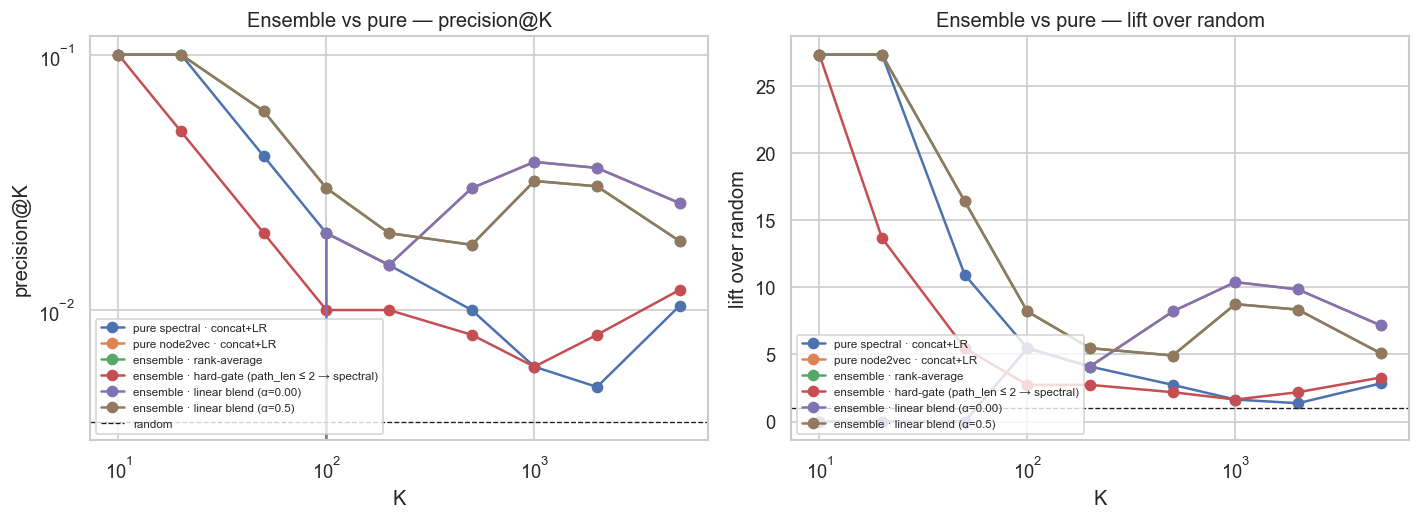

In [25]:
# Visual — Top-K precision curves for the ensembles vs the pure methods
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, s in ensembles.items():
    st = s[idx_test]
    order = np.argsort(-st)
    yy = y_test[order]
    ks = np.array([10, 20, 50, 100, 200, 500, 1000, 2000, 5000])
    prec = np.array([yy[:k].sum() / k for k in ks])
    axes[0].plot(ks, prec, marker="o", label=name)
    axes[1].plot(ks, prec / prior, marker="o", label=name)
axes[0].axhline(prior, color="k", ls="--", lw=0.8, label="random")
axes[0].set(xscale="log", yscale="log", xlabel="K", ylabel="precision@K",
            title="Ensemble vs pure — precision@K")
axes[0].legend(fontsize=7, loc="lower left")
axes[1].axhline(1.0, color="k", ls="--", lw=0.8)
axes[1].set(xscale="log", xlabel="K", ylabel="lift over random",
            title="Ensemble vs pure — lift over random")
axes[1].legend(fontsize=7, loc="lower left")
plt.tight_layout()


**Reading the ensemble table:**

- If **rank-average** beats both pure methods, the two rankers already disagree in useful ways — no gate needed.
- If **hard-gate** beats rank-average, the disagreement is systematically explained by C–D graph distance — supports the "spectral is local, node2vec is global" story.
- If **linear blend α=0.5** ≈ rank-average, but tuned α ≠ 0.5, one method carries most of the signal; the other adds only marginal corrections.

Whichever wins, it is directly consumable: the winning ensemble is `test_pair_features.parquet` × `ensembles[winning_name]` — one column away from being deployed.

In [26]:
# Persist the winning-ensemble scores plus the discrepancy features together
ens_out = pairs[["compound", "disease", "y"]].copy()
ens_out["score_spectral_pct"] = pct_spectral
ens_out["score_n2v_pct"]      = pct_n2v
ens_out["score_rank_avg"]     = score_avg
ens_out["score_hard_gate"]    = score_gate
ens_out["score_linear_tuned"] = score_lin_tuned
ens_out["in_test"]            = test_mask
ens_out.to_parquet(ART / "predictions" / "ensembles.parquet")

# Convert multi-index keys (method, K) to strings for JSON compatibility
decomp_dict = {
    f"{m} | K={k}": v
    for (m, k), v in decomp.set_index(["method", "K"]).round(2).to_dict(orient="index").items()
}
group_stats_dict     = {str(k): v for k, v in group_stats.to_dict(orient="index").items()}
pos_split_dict       = {str(k): v for k, v in pos_split.to_dict(orient="index").items()}

integration_meta = {
    "produced_by": "06_evaluation_deepdive.ipynb §6",
    "top_k_by_structure":       decomp_dict,
    "rank_diff_by_outlier":     group_stats_dict,
    "positive_rank_by_outlier": pos_split_dict,
    "ensemble_results":         ens_df.set_index("method").to_dict(orient="index"),
    "linear_blend_curve":       alpha_df.round(4).to_dict(orient="records"),
    "best_alpha":               alpha_best,
    "outlier_endpoints": {
        "compound": sorted(hd_ids["Compound"]),
        "disease":  sorted(hd_ids["Disease"]),
    },
}
(ART / "predictions" / "integration_meta.json").write_text(json.dumps(integration_meta, indent=2, default=str))
print("Wrote:")
print("  artifacts/predictions/ensembles.parquet")
print("  artifacts/predictions/integration_meta.json")


Wrote:
  artifacts/predictions/ensembles.parquet
  artifacts/predictions/integration_meta.json
